# Series 02 — Sine Waves: From Theory to Code

This notebook generates and plots sine waves, from a rough draft to a clean, well-documented version.

**To Do:**
1. Plot a sine wave (draft version)
2. Add a cosine wave, a legend, and a second y-axis (improved version)
3. Create a `sinusoid` function, compare two frequencies, and clean up the code (final version)

## 1. What is a sinusoid?

A sinusoid is a signal that varies over time following a sine function:

$$ s(t) = A \sin(\omega t + \varphi) $$

where:
- $A$ is the amplitude (maximum height of the signal), same unit as $s(t)$
- $\omega$ is the angular frequency, in rad/s
- $\varphi$ is the phase, in radians (rad)
- $t$ is time, in seconds (s)

### Angular frequency: $\omega$

The angular frequency $\omega$ measures how fast the phase of the signal changes over time. It is related to the ordinary frequency $f$ (in Hz) and the period $T$ (in seconds) by:

$$ \omega = 2\pi f = \dfrac{2\pi}{T} $$

- $f$: frequency, in Hz (number of oscillations per second)
- $T$: period, in seconds (s) — the time to complete one full oscillation, $T = 1/f$
- $\omega$: angular frequency, in rad/s — the "speed" of rotation around the unit circle that generates the sinusoid

### TODO 

- Import the needed libraries
- Create a numpy array called t that contains 1000 values from 0 to 1 (t is for time)
- Create a numpy array called s that contains the values of a sine function of t (s is for signal)
- Plot s as a function of t
- Add a title to the plot
- Add a label to the x axis
- Add a label to the y axis
- Add a grid to the plot
- Save the plot as a png file


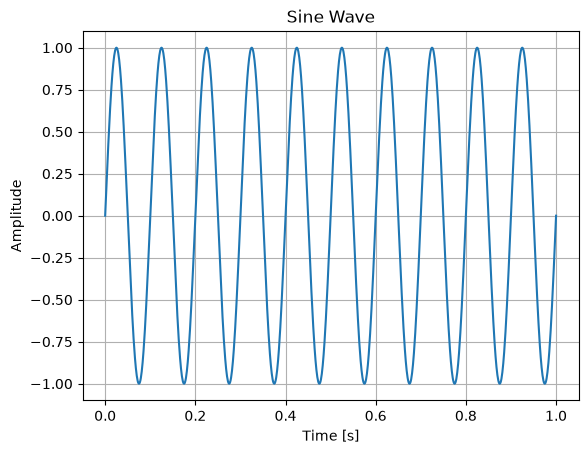

In [69]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 1000)  # 1000 points for a smooth-looking curve over 1 second

def s(t, amplitude, angular_frequency, phase):
    # sine wave: s(t) = A * sin(omega*t + phi)
    return amplitude * np.sin(angular_frequency * t + phase)

amplitude = 1
angular_frequency = 2 * np.pi * 10  # 10 Hz chosen so several full oscillations are visible over 1 s
phase = 0

plt.plot(t, s(t, amplitude, angular_frequency, phase))
plt.title('Sine Wave')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()  # gridlines make it easier to read exact values off the curve
plt.savefig('sine_wave.png', dpi=300)  # high resolution, suitable for printing/reports

## 2. Improved version

**Check:** commit history is understandable, with clear commit messages, and code is clean and well-documented. If not, improve it and commit the changes.

### TODO
1. Create a new branch in the Git repository
2. Improve the previous notebook by adding:
   1. A second plot: cosine function of `t`, in the same figure
   2. A legend
   3. A second y axis
   4. A second label for that y axis
   5. Save the plot as a PDF file

### From sine to cosine: a 90° phase shift

We don't need a new formula: a cosine is simply the same sine wave, rotated by a quarter turn (90° or $\pi/2$ radians) on the trigonometric circle.

Starting from the base sinusoid:

$$ s(t) = A \sin(\omega t + \varphi) $$

we obtain a cosine by adding $\pi/2$ to the phase $\varphi$:

$$ \cos(\omega t) = \sin\left(\omega t + \frac{\pi}{2}\right) $$

So the cosine wave is generated by reusing the exact same `s()` function, just with `phase = np.pi / 2` instead of `phase = 0`.

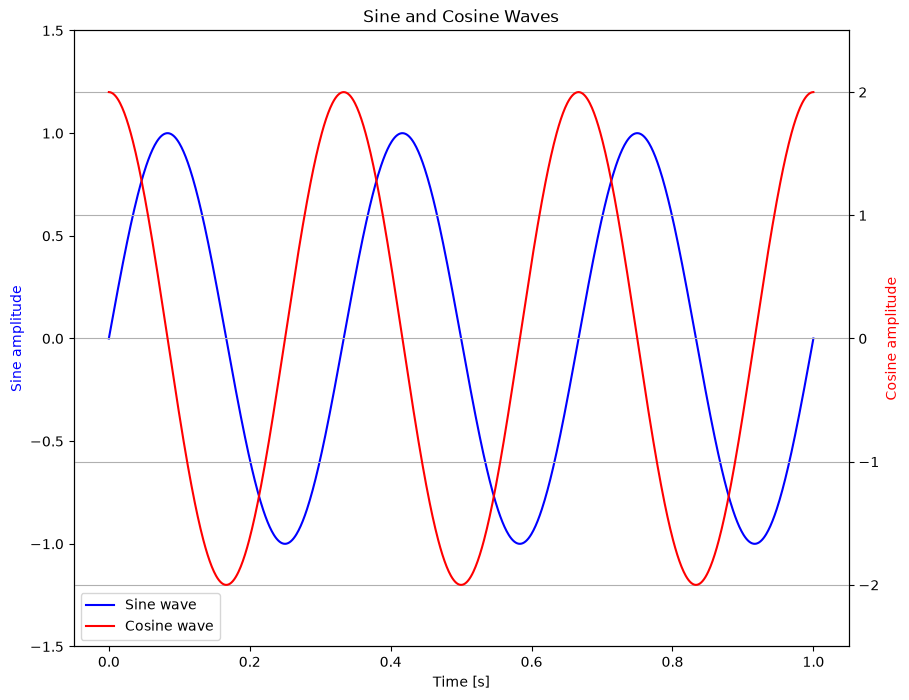

In [70]:
# --- Figure setup ---
fig, ax1 = plt.subplots(figsize=(10, 8))  # larger figure to leave room for the legend and both y-axis labels

# --- Sine wave parameters ---
amplitude = 1
angular_frequency = 2 * np.pi * 3  # 3 Hz
phase = 0  # sine starts at 0

# --- Sine wave plot (left y axis) ---
ax1.plot(t, s(t, amplitude, angular_frequency, phase), color='blue', label='Sine wave')
ax1.set_ylim(-1.5, 1.5)  # small margin above/below amplitude=1 so the curve doesn't touch the frame
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Sine amplitude', color='blue')

# --- Second y axis setup ---
ax2 = ax1.twinx()  # separate y-scale needed because cosine has a different amplitude (2 vs 1);
                    # twinx keeps both signals on the same time axis for direct comparison

# --- Cosine wave parameters ---
amplitude = 2
angular_frequency = 2 * np.pi * 3  # 3 Hz
phase = np.pi / 2  # phase shift of 90°: cosine = shifted sine

# --- Cosine wave plot (right y axis) ---
ax2.plot(t, s(t, amplitude, angular_frequency, phase), color='red', label='Cosine wave')
ax2.set_ylim(-2.5, 2.5)  # margin consistent with sine axis, scaled to amplitude=2
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Cosine amplitude', color='red')

# --- Combined legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')  # twinx axes don't share a legend automatically,
                                                                    # so handles/labels must be merged manually

# --- Final touches and export ---
plt.grid()  # gridlines make it easier to read values off the curves
plt.title('Sine and Cosine Waves')
plt.savefig('sine_and_cosine_waves.pdf')  # PDF: vector format, keeps quality when scaled/printed




## 3. Final version

**Check:** previous commit history is understandable and code is clean. If not, improve it and commit the changes.

**To do:**
1. Create a new branch in the Git repository
2. Improve the notebook with better code organization:
   1. Create a function `sinusoid` that takes all needed parameters and returns a numpy array `x`
   2. Use `sinusoid` to create two arrays `s1` and `s2` with two different frequencies
   3. Plot `s1` and `s2` as a function of `t`
3. Apply best practices for research code quality:
   - meaningful variable names everywhere
   - comments explaining *why*, not *what*
   - docstrings for all functions
   - references to sources used (Markdown cell at the end, like a bibliography)

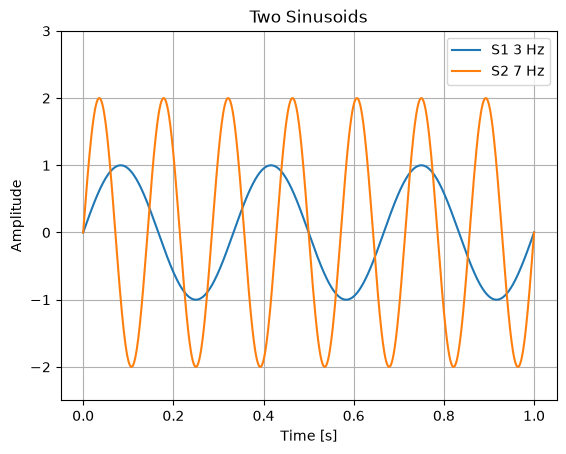

In [ ]:
def sinusoid(t, amplitude, angular_frequency, phase):
    """
    Generate a sinusoidal signal.

    Parameters:
    t (numpy.ndarray): Time array.
    amplitude (float): Amplitude of the sinusoid.
    angular_frequency (float): Angular frequency (rad/s).
    phase (float): Phase shift (radians).

    Returns:
    numpy.ndarray: Sinusoidal signal values.
    """
    x = amplitude * np.sin(angular_frequency * t + phase)
    return x

# --- Generate two sinusoids with different frequencies ---
s1 = sinusoid(t, 1, 2 * np.pi * 3, 0)  # light frequency and amplitude, to make the two signals easy to tell apart visually
s2 = sinusoid(t, 2, 2 * np.pi * 7, 0) # higher frequency and amplitude, to make the two signals easy to tell apart visually

# --- Plot both signals for comparison ---
plt.plot(t, s1)
plt.plot(t, s2)
plt.ylim(-2.5, 3)  # extra space so the legend doesn't overlap the curves
plt.legend(['S1 3 Hz', 'S2 7 Hz'], loc='upper right')
plt.title('Two Sinusoids')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()  # easier to read values


## Sources

- Matplotlib documentation: `pyplot.subplots`, `Axes.twinx`, `Axes.legend`, `Axes.get_legend_handles_labels`
- Course materials (IEAP Python Series 02) on sine and cosine formulas and the definition of angular frequency
- AI assistant (Claude) to help me understand the requirements and grasp Python commands and syntax. It corrects my work, assists with my English-to-French translations, and helps me find the commands I need